# Auto-encodeurs simples avec Keras

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'execution` et vérifiez que l'on est bien en Python 3 et que l'accélérateur matériel est configuré sur « GPU ».

In [1]:
!nvidia-smi

Tue Mar 31 05:41:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import de TensorFlow et des autres librairies nécessaires

In [2]:
import matplotlib.pyplot as plt
import numpy
import scipy.interpolate
import keras

## Chargement de MNIST

Nous allons utiliser un prétraîtement légèrement différent des autres fois : étant donné que nous voulons pouvoir prédire les valeurs données en entrée en sortie (principe de l'auto-encodage), nous allons simplement projeter ces valeurs dans $[0, 1]$ au lieu de $[0, 255]$. Notez qu'habituellement nous ne faisons pas ça : nous normalisons en centrant sur zéro et en divisant par l'écart-type.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
nb_classes = 10
input_dim = 28 * 28
X_train = X_train.reshape(-1, input_dim) / 255.0
X_test = X_test.reshape(-1, input_dim) / 255.0

In [4]:
X_train.shape

(60000, 784)

## Création de l'autoencodeur

In [5]:
encoding_dim = 4

encoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(encoding_dim, activation="leaky_relu")],
    name="encoder")

decoder = keras.Sequential(
    [keras.layers.Input(shape=(encoding_dim,)),
     keras.layers.Dense(input_dim, activation="sigmoid")],
    name="decoder")

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)), encoder, decoder],
    name="autoencoder")
autoencoder.summary()

autoencoder.compile(optimizer="adam", loss="mean_squared_error")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │         3,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,060 (27.58 KB)

 Trainable params: 7,060 (27.58 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
encoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(encoding_dim, activation="leaky_relu")],
    name="encoder")

decoder = keras.Sequential(
    [keras.layers.Input(shape=(encoding_dim,)),
     keras.layers.Dense(50,  activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(150, activation="leaky_relu"),
     keras.layers.Dense(input_dim,
                        activation="sigmoid",
                        kernel_initializer="orthogonal")],
    name="decoder")

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)), encoder, decoder],
    name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mean_squared_error")


encoder.summary()
decoder.summary()
autoencoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 150)            │       117,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,454 (755.68 KB)

 Trainable params: 193,454 (755.68 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 4)              │       193,454 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       194,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,688 (1.48 MB)

 Trainable params: 387,688 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## Apprentissage

In [7]:
autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=256,
                validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0764 - val_loss: 0.0592
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0533 - val_loss: 0.0488
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0461 - val_loss: 0.0432
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0394 - val_loss: 0.0368
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0358 - val_loss: 0.0347
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0339 - val_loss: 0.0333
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0327 - val_loss: 0.0327
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0317 - val_loss: 0.0316
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0311 - val_loss: 0.0311
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0304 - val_loss: 0.0305
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0299 - val_loss: 0.0300
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

## Prédiction sur du bruit blanc

Pour une première utilisation du décodeur, on peut regarder ce qu'il prédit sur du bruit blanc en entrée.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


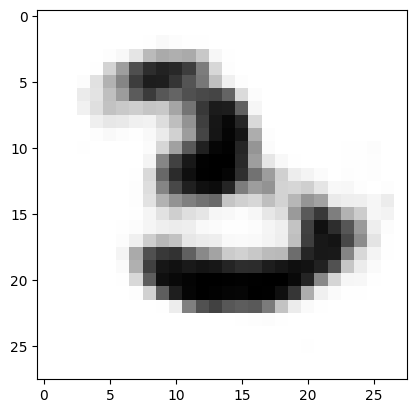

In [8]:
white_noise = numpy.random.random_sample((1, encoding_dim))
plt.imshow(decoder.predict(white_noise).reshape(28, 28), cmap="gray_r")
plt.show()

## Encodage des données de test

On peut aussi, grâce à l'encodeur récupéré, encoder nos données de test vers l'espace de dimension `encoding_dim` appris.

In [9]:
codes = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [10]:
codes.shape

(10000, 4)

## Calcul des centroïdes de chaque chiffre dans l'espace de codage

Un autre point intéressant est de regarder en moyenne où atterrissent les exemples d'un label donné dans l'espace de codage.

In [11]:
means = numpy.vstack([codes[y_test == i].mean(axis=0)
                      for i in range(nb_classes)])
stds = numpy.vstack([codes[y_test == i].std(axis=0)
                     for i in range(nb_classes)])

# Étude rapide des codages en test
for i in range(10):
  dimension_stats = [f"{mean:5.2f}±{std:.2f}"
                     for mean, std in zip(means[i], stds[i])]
  print(f"Classe {i} {', '.join(dimension_stats)}")

Classe 0  2.49±2.13,  5.03±2.81, -3.13±1.02, 11.11±2.87
Classe 1 17.09±3.58, 15.41±3.85, -2.09±1.22,  6.96±2.75
Classe 2  2.57±1.83,  6.79±2.32, -1.86±1.06,  1.41±1.83
Classe 3  2.83±1.48,  4.15±1.87, -1.34±0.76,  3.62±1.33
Classe 4  9.37±2.12,  4.59±2.72, -3.58±0.98,  5.74±2.07
Classe 5  6.39±2.66,  7.94±4.45, -3.06±1.21,  7.83±2.44
Classe 6 10.32±2.90,  6.52±3.68, -2.95±1.13, 13.47±3.40
Classe 7 12.47±2.85,  5.09±2.77, -2.80±1.18,  2.78±1.75
Classe 8  5.82±2.26,  7.26±3.03, -3.32±1.24,  4.62±1.61
Classe 9 12.68±2.79,  5.61±2.19, -4.17±1.18,  7.06±2.18


On peut à partir de là vérifier que chaque centroïde est bien décodé par quelque chose de vraisemblable par le décodeur.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


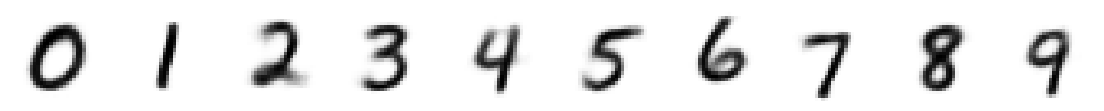

In [12]:
f, ax = plt.subplots(1, nb_classes, figsize=(1.4 * nb_classes, 2))

centroid_images = decoder.predict(means).reshape(-1, 28, 28)

for i, centroid_image in enumerate(centroid_images):
  ax[i].imshow(centroid_image, cmap="gray_r")
  ax[i].axis("off")
plt.show()

## Parcours de l'espace latent entre deux centroïdes

Maintenant que l'on sait où se trouvent les centroïdes pour un chiffre donné dans l'espace latent, on peut parcourir l'espace entre deux centroïdes pour mieux comprendre comment l'espace latent est structuré.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


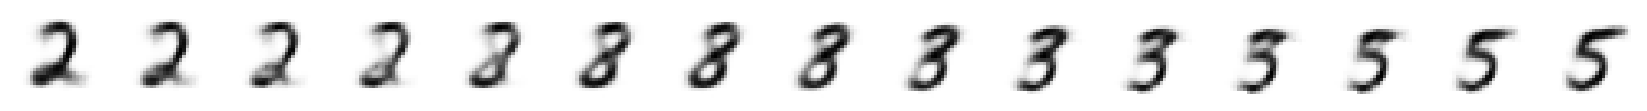

In [13]:
def latent_walk(start: int, end: int, n: int = 15):
  interpolator = scipy.interpolate.interp1d([0, n - 1],
                                            means[[start, end], :],
                                            axis=0)
  interpolated_codes = interpolator(range(n))
  interpolated_images = decoder.predict(interpolated_codes).reshape(-1, 28, 28)

  f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
  for i, interpolated_image in enumerate(interpolated_images):
    ax[i].imshow(interpolated_image, cmap="gray_r")
    ax[i].axis("off")
  plt.show()


latent_walk(2, 5)

## Auto-encodage de toute la base de test

In [14]:
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Évaluation visuelle de la performance

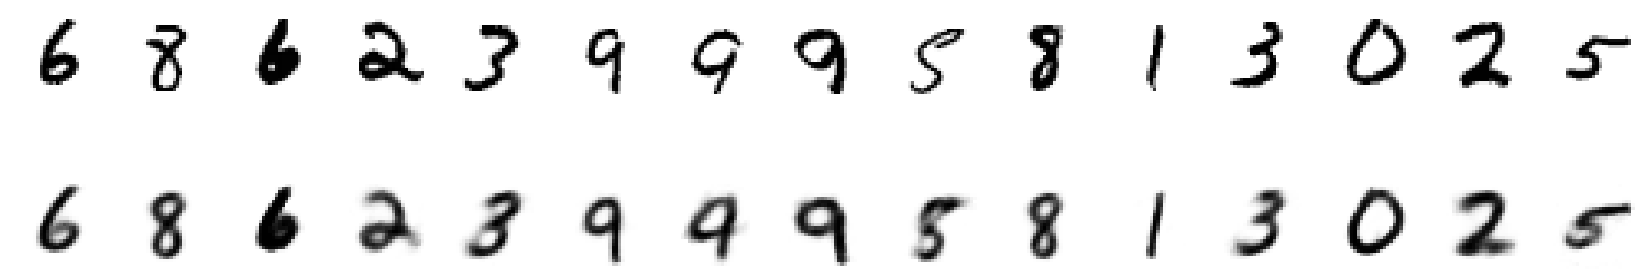

In [15]:
n = 15  # Nombre de chiffres que nous allons afficher

random_indexes = numpy.random.choice(X_test_pred.shape[0],
                                     size=n,
                                     replace=False)

_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, random_index in enumerate(random_indexes):
    # L'original en haut
    ax[0, i].imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(X_test_pred[random_index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

## Détection d'anomalies

Il est possible de détecter des anomalies dans les données en utilisant l'erreur de reconstruction : une grande erreur induit que l'exemple est hors de la distribution normale des données.

Pires reconstructions sur le train


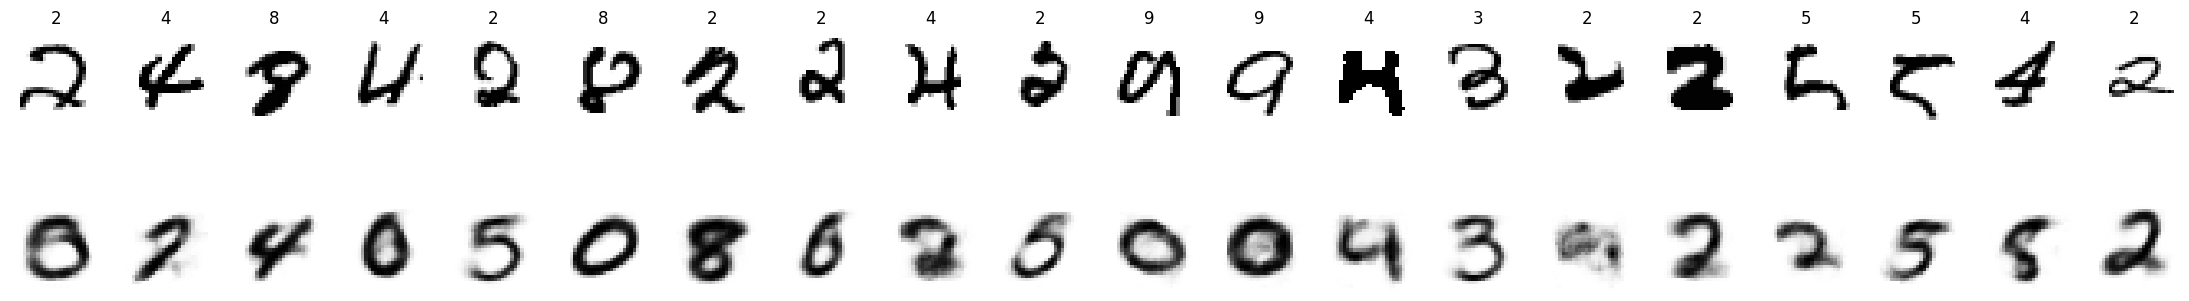

Pires reconstructions sur le test


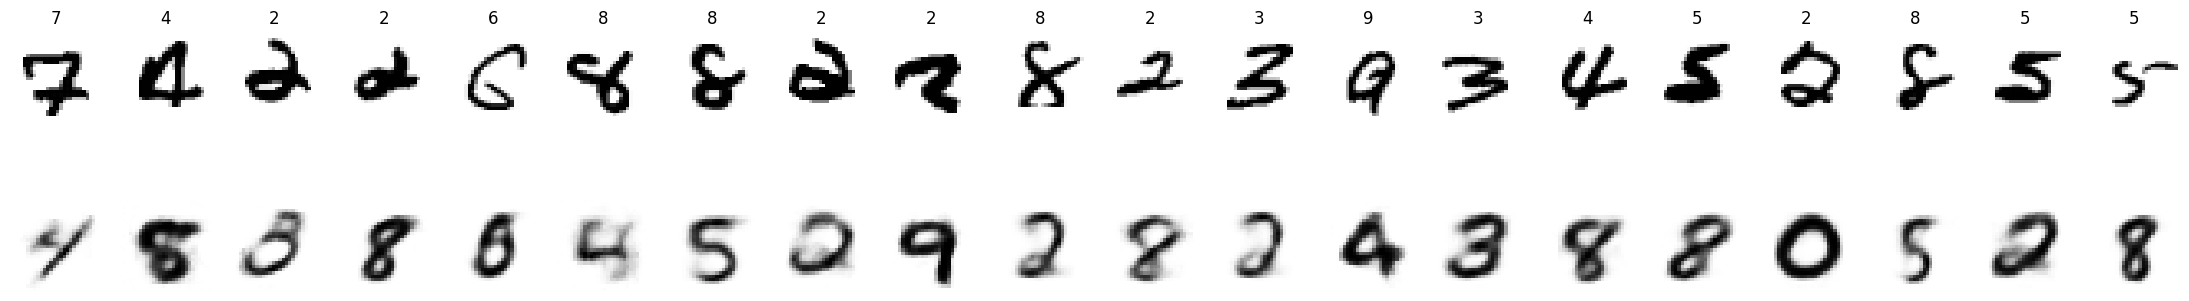

Meilleures reconstructions sur le train


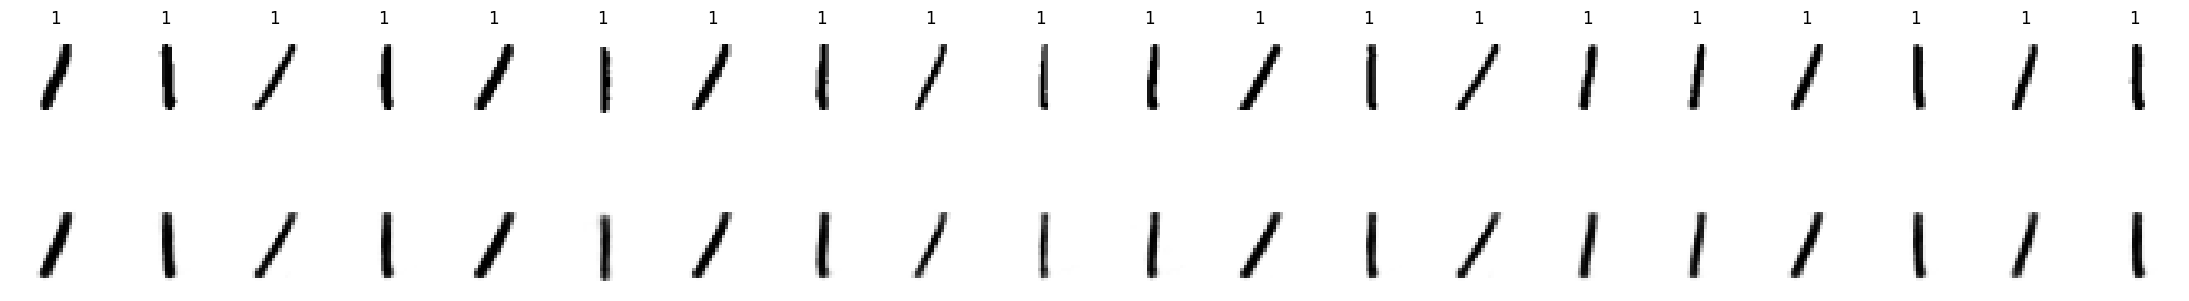

Meilleures reconstructions sur le test


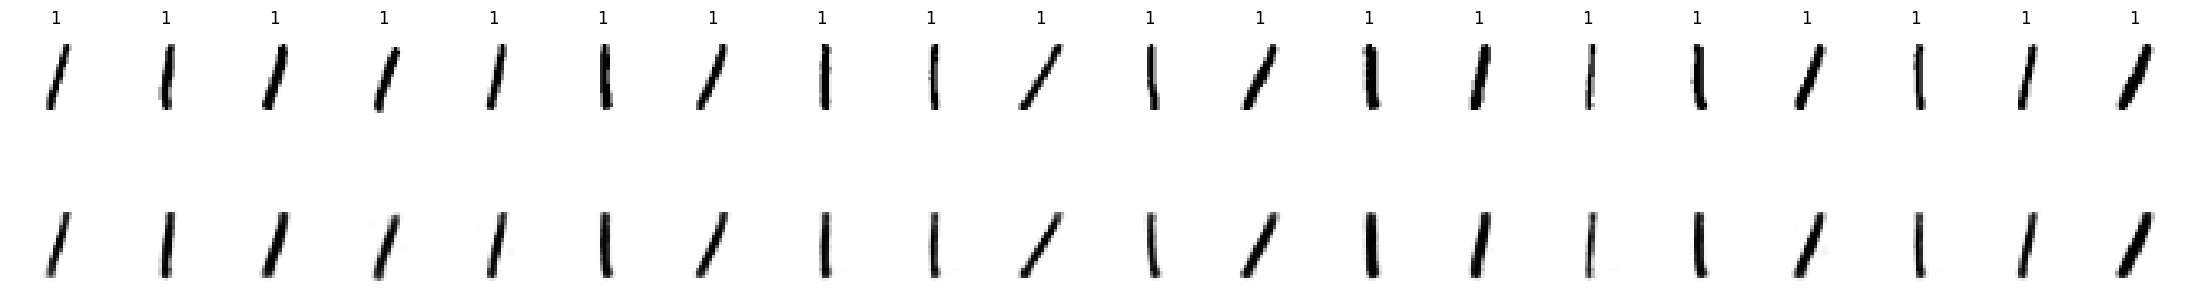

In [16]:
mse = keras.losses.MeanSquaredError(reduction="none")
test_anomalies = (-mse(X_test_pred, X_test).numpy()).argsort()
train_anomalies = (-mse(X_train_pred, X_train).numpy()).argsort()

n = 20

print("Pires reconstructions sur le train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[:n]):
    # L'original en haut
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(X_train_pred[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Pires reconstructions sur le test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[:n]):
    # L'original en haut
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(X_test_pred[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()

print("Meilleures reconstructions sur le train")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(train_anomalies[-n:]):
    # L'original en haut
    ax[0, i].set_title(y_train[index])
    ax[0, i].imshow(X_train[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(X_train_pred[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()


print("Meilleures reconstructions sur le test")
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, index in enumerate(test_anomalies[-n:]):
    # L'original en haut
    ax[0, i].set_title(y_test[index])
    ax[0, i].imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax[0, i].axis("off")

    # La reconstruction en bas
    ax[1, i].imshow(X_test_pred[index].reshape(28, 28), cmap="gray_r")
    ax[1, i].axis("off")
plt.show()